# Control-Theoretic Analysis of the Resonate-and-Fire Neuron

This notebook treats a Resonate-and-Fire (RF) neuron as a driven, damped harmonic oscillator (RLC analog)
and analyzes it using classical control theory tools. We interpret the membrane voltage $v(t)$ as the output
and the input current $I(t)$ as the forcing function.

Key model equation:
$$ \ddot{v} + 2\zeta\omega_n\dot{v} + \omega_n^2 v = I(t) $$


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sympy as sp

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.grid': True,
    'font.size': 11,
})


## Section 1: Fundamental Control Theory of the RF Neuron

### State-Space Representation
Let $x_1 = v$ and $x_2 = \dot{v}$. Then
$$
\dot{x}_1 = x_2, \quad
\dot{x}_2 = -2\zeta\omega_n x_2 - \omega_n^2 x_1 + I(t)
$$

So the state-space form is
$$
\dot{\mathbf{x}} = \mathbf{A}\mathbf{x} + \mathbf{B}I(t), \quad
v = \mathbf{C}\mathbf{x}
$$
with
$$
\mathbf{A} = \begin{bmatrix} 0 & 1 \;\; -\omega_n^2 & -2\zeta\omega_n \end{bmatrix},
\quad
\mathbf{B} = \begin{bmatrix} 0 \;\; 1 \end{bmatrix},
\quad
\mathbf{C} = \begin{bmatrix} 1 & 0 \end{bmatrix}.
$$

### Transfer Function
Taking the Laplace transform with zero initial conditions:
$$
H(s) = \frac{V(s)}{I(s)} = \frac{1}{s^2 + 2\zeta\omega_n s + \omega_n^2}.
$$

The quality factor is
$$
Q = \frac{1}{2\zeta}.
$$
A smaller $\zeta$ (higher $Q$) yields stronger resonance but longer ringing.

### Impulse Response
For input $I(t) = \delta(t)$ and $0 < \zeta < 1$, the impulse response is
$$
h(t) = \frac{1}{\omega_d} e^{-\zeta\omega_n t} \sin(\omega_d t),
\quad \omega_d = \omega_n\sqrt{1-\zeta^2}.
$$


In [62]:
# Symbolic transfer function and impulse response
s, zeta, wn, t = sp.symbols('s zeta wn t', positive=True)
H = 1 / (s**2 + 2*zeta*wn*s + wn**2)
sp.simplify(H)


1/(s**2 + 2*s*wn*zeta + wn**2)

In [63]:
# Inverse Laplace (underdamped case)
wd = sp.sqrt(wn**2 * (1 - zeta**2))
h_t = sp.exp(-zeta*wn*t) * sp.sin(wd*t) / wd
sp.simplify(h_t)


exp(-t*wn*zeta)*sin(t*wn*sqrt(1 - zeta**2))/(wn*sqrt(1 - zeta**2))

### Numerical Impulse Response and Bode Plot
The RF neuron behaves like a resonant second-order system with a pronounced peak near $\omega_n$.
The Bode magnitude shows this resonance and the phase transition around the natural frequency.


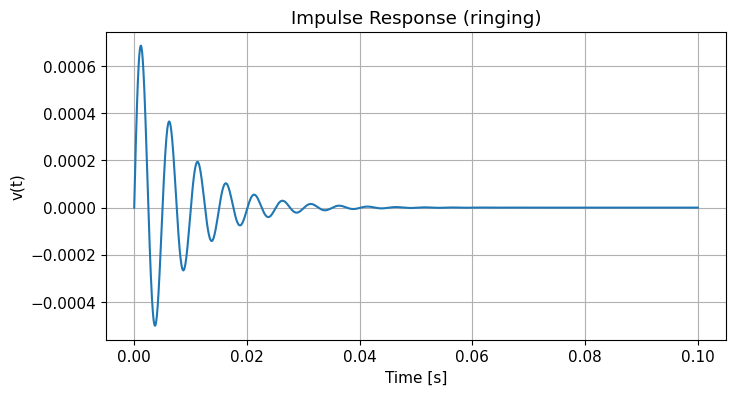

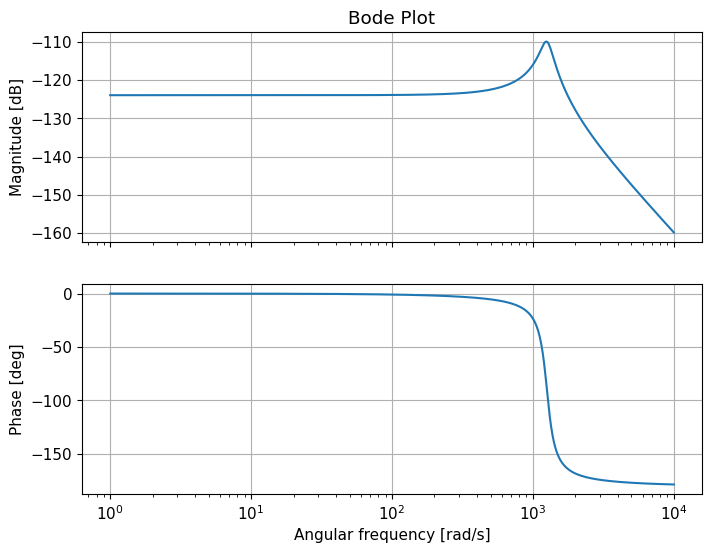

In [64]:
# Nominal parameters
wn_val = 2 * np.pi * 200.0  # rad/s
zeta_val = 0.1

sys = signal.TransferFunction([1.0], [1.0, 2*zeta_val*wn_val, wn_val**2])

# Impulse response
t_imp, y_imp = signal.impulse(sys, T=np.linspace(0, 0.1, 2000))
plt.plot(t_imp, y_imp)
plt.title('Impulse Response (ringing)')
plt.xlabel('Time [s]')
plt.ylabel('v(t)')
plt.show()

# Bode plot
w = np.logspace(0, 4, 800)
w, mag, phase = signal.bode(sys, w=w)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
ax[0].semilogx(w, mag)
ax[0].set_ylabel('Magnitude [dB]')
ax[0].set_title('Bode Plot')
ax[1].semilogx(w, phase)
ax[1].set_ylabel('Phase [deg]')
ax[1].set_xlabel('Angular frequency [rad/s]')
plt.show()


### Parametric Analysis ($\omega_n$ and $\zeta$)
- Increasing $\omega_n$ shifts the resonant peak to higher frequencies.
- Increasing $\zeta$ lowers the peak and broadens the bandwidth.
- The approximate bandwidth relates to the quality factor: $BW \approx \omega_n / Q$.


### State-Space Stability and Eigenvalues (Symplectic Euler note)
A common symplectic Euler implementation uses the state ordering $x = [\dot{v}, v]^T$, which yields
$$
\mathbf{A} = \begin{bmatrix} -2\zeta\omega_n & -\omega_n^2 \;\; 1 & 0 \end{bmatrix}.
$$
If $v$ is rescaled by $\omega_n^2$, an equivalent form often appears as
$$
\mathbf{A} = \begin{bmatrix} -2\zeta\omega_n & -1 \;\; \omega_n^2 & 0 \end{bmatrix}.
$$
In all cases, the eigenvalues are
$$
\lambda = -\zeta\omega_n \pm j\omega_d, \quad \omega_d = \omega_n\sqrt{1-\zeta^2},
$$
and stability requires a negative real part.


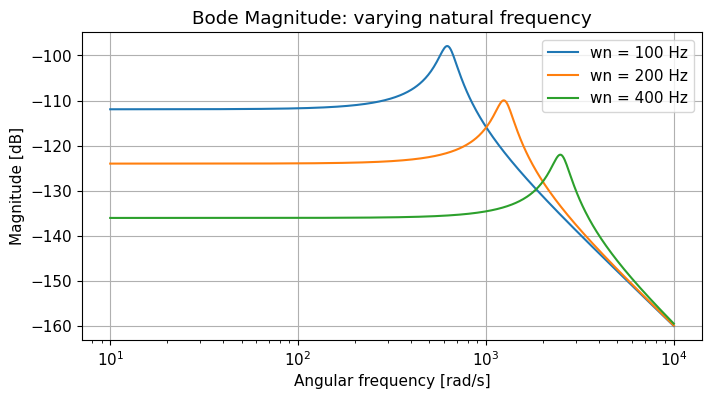

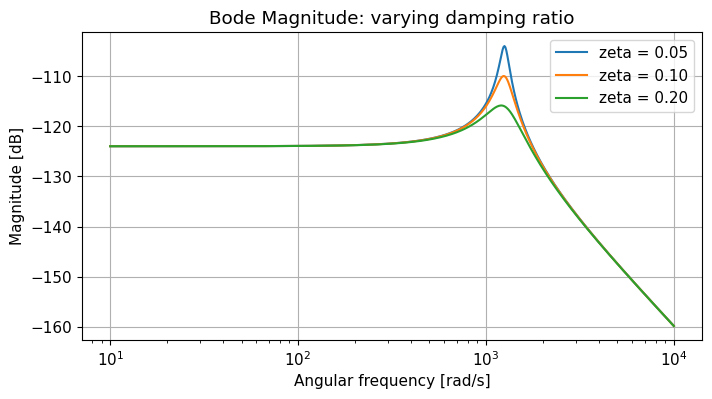

In [65]:
w = np.logspace(1, 4, 600)
zeta_val = 0.1
wn_list = [2*np.pi*100, 2*np.pi*200, 2*np.pi*400]
zeta_list = [0.05, 0.1, 0.2]

# Vary natural frequency
plt.figure(figsize=(8, 4))
for wn_val in wn_list:
    sys = signal.TransferFunction([1.0], [1.0, 2*zeta_val*wn_val, wn_val**2])
    _, mag, _ = signal.bode(sys, w=w)
    plt.semilogx(w, mag, label=f'wn = {wn_val/(2*np.pi):.0f} Hz')
plt.title('Bode Magnitude: varying natural frequency')
plt.xlabel('Angular frequency [rad/s]')
plt.ylabel('Magnitude [dB]')
plt.legend()
plt.show()

# Vary damping ratio
plt.figure(figsize=(8, 4))
for zeta_val in zeta_list:
    sys = signal.TransferFunction([1.0], [1.0, 2*zeta_val*wn_list[1], wn_list[1]**2])
    _, mag, _ = signal.bode(sys, w=w)
    plt.semilogx(w, mag, label=f'zeta = {zeta_val:.2f}')
plt.title('Bode Magnitude: varying damping ratio')
plt.xlabel('Angular frequency [rad/s]')
plt.ylabel('Magnitude [dB]')
plt.legend()
plt.show()


## Section 2: Echolocation and Distance Measurement (Bat Model)

We model a dual-impulse input representing the corollary discharge (inhibitory) and the returning echo
(excitatory):
$$
I(t) = -A_{inh}\delta(t) + A_{exc}\delta(t - \tau)
$$
where $\tau$ is the time-of-flight (ToF).

The output is a superposition of impulse responses: 
$$
v(t) = -A_{inh} h(t) + A_{exc} h(t-\tau).
$$
A resonance match occurs when the neuron's natural period $T = 2\pi/\omega_n$ aligns with $\tau$,
producing constructive interference and a large peak (phase kick).


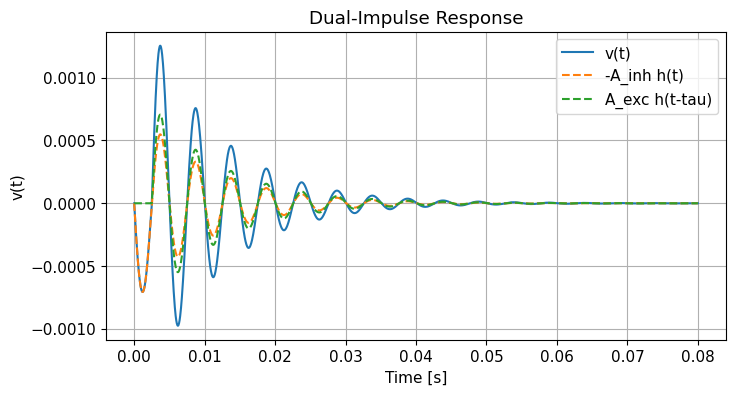

In [89]:
def impulse_response(t, wn, zeta):
    wd = wn * np.sqrt(1 - zeta**2)
    h = np.zeros_like(t)
    mask = t >= 0
    h[mask] = np.exp(-zeta*wn*t[mask]) * np.sin(wd*t[mask]) / wd
    return h

# Dual-impulse parameters
wn_val = 2 * np.pi * 200.0
zeta_val = 0.08
A_inh = 1.0
A_exc = 1.0
tau = 0.5 / 200.0  # seconds, change for impulse timing

t = np.linspace(0, 0.08, 2000)
h = impulse_response(t, wn_val, zeta_val)
h_shift = impulse_response(t - tau, wn_val, zeta_val)
v = -A_inh * h + A_exc * h_shift

plt.plot(t, v, label='v(t)')
plt.plot(t, -A_inh*h, '--', label='-A_inh h(t)')
plt.plot(t, A_exc*h_shift, '--', label='A_exc h(t-tau)')
plt.title('Dual-Impulse Response')
plt.xlabel('Time [s]')
plt.ylabel('v(t)')
plt.legend()
plt.show()


### Distance Tuning and a Bank of Neurons
Assuming a round-trip delay $\tau = 2d/c$ (distance $d$, propagation speed $c$),
the resonance match condition is
$$
T = \frac{2\pi}{\omega_n} \approx \tau = \frac{2d}{c}.
$$
So a bank of neurons tuned to distances $d$ should use
$$
\omega_n(d) = \frac{2\pi}{\tau} = \frac{\pi c}{d}.
$$
For acoustic echolocation, a typical choice is $c = 343\ 	ext{m/s}$.
For radar, set $c = 3\times10^8\ 	ext{m/s}$.


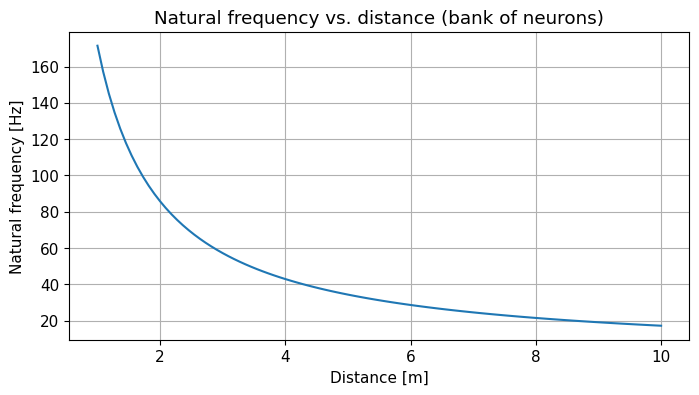

d = 1.0 m -> wn = 1077.57 rad/s (171.50 Hz)
d = 1.1 m -> wn = 987.77 rad/s (157.21 Hz)
d = 1.2 m -> wn = 911.79 rad/s (145.12 Hz)
d = 1.3 m -> wn = 846.66 rad/s (134.75 Hz)
d = 1.4 m -> wn = 790.22 rad/s (125.77 Hz)
d = 1.5 m -> wn = 740.83 rad/s (117.91 Hz)
d = 1.5 m -> wn = 697.25 rad/s (110.97 Hz)
d = 1.6 m -> wn = 658.51 rad/s (104.81 Hz)
d = 1.7 m -> wn = 623.85 rad/s (99.29 Hz)
d = 1.8 m -> wn = 592.66 rad/s (94.32 Hz)
d = 1.9 m -> wn = 564.44 rad/s (89.83 Hz)
d = 2.0 m -> wn = 538.78 rad/s (85.75 Hz)
d = 2.1 m -> wn = 515.36 rad/s (82.02 Hz)
d = 2.2 m -> wn = 493.88 rad/s (78.60 Hz)
d = 2.3 m -> wn = 474.13 rad/s (75.46 Hz)
d = 2.4 m -> wn = 455.89 rad/s (72.56 Hz)
d = 2.5 m -> wn = 439.01 rad/s (69.87 Hz)
d = 2.5 m -> wn = 423.33 rad/s (67.38 Hz)
d = 2.6 m -> wn = 408.73 rad/s (65.05 Hz)
d = 2.7 m -> wn = 395.11 rad/s (62.88 Hz)
d = 2.8 m -> wn = 382.36 rad/s (60.85 Hz)
d = 2.9 m -> wn = 370.41 rad/s (58.95 Hz)
d = 3.0 m -> wn = 359.19 rad/s (57.17 Hz)
d = 3.1 m -> wn = 348.62 

In [67]:
# Bank of neuron frequencies for distances 1m to 10m
c = 343.0  # m/s (sound); swap to 3e8 for radar
d = np.linspace(1.0, 10.0, 100)
tau = 2 * d / c
wn = 2 * np.pi / tau

plt.plot(d, wn / (2*np.pi))
plt.title('Natural frequency vs. distance (bank of neurons)')
plt.xlabel('Distance [m]')
plt.ylabel('Natural frequency [Hz]')
plt.show()

for di, wni in zip(d, wn):
    print(f'd = {di:.1f} m -> wn = {wni:.2f} rad/s ({wni/(2*np.pi):.2f} Hz)')


### Optimization Trade-Off: Temporal Precision vs. Frequency Selectivity
- High damping (large $\zeta$): fast decay, sharper timing, weaker resonance.
- Low damping (small $\zeta$): strong resonance, better frequency selectivity, longer ringing.

Below we compare impulse responses at different damping ratios to illustrate this trade-off.


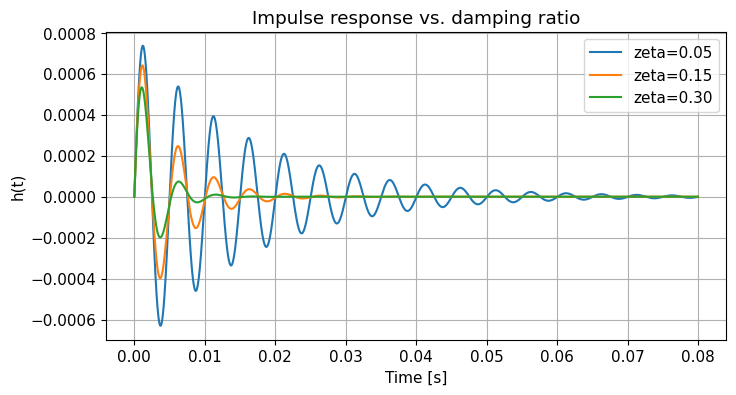

In [68]:
wn_val = 2 * np.pi * 200.0
t = np.linspace(0, 0.08, 2000)

plt.figure(figsize=(8, 4))
for zeta_val in [0.05, 0.15, 0.3]:
    h = impulse_response(t, wn_val, zeta_val)
    plt.plot(t, h, label=f'zeta={zeta_val:.2f}')
plt.title('Impulse response vs. damping ratio')
plt.xlabel('Time [s]')
plt.ylabel('h(t)')
plt.legend()
plt.show()


## Control-Theory Anchors Recap
1. **Quality Factor**: $Q = 1/(2\zeta)$ controls resonance sharpness and ringing duration.
2. **Phase Kick**: the echo triggers a large response if it arrives near the peak of the ongoing oscillation.
3. **Stability**: the eigenvalues of $\mathbf{A}$ are $\lambda = -\zeta\omega_n \pm j\omega_d$.
   The real part must be negative for stability (decaying oscillations).


## Extended Analysis: Damping, Tuned Frequency, and Distance Mapping

### 1) Damped Frequency vs. Distance
For a neuron tuned to distance $d$, the round-trip delay is $\tau = 2d/c$, so
$$
\omega_n(d) = \frac{2\pi}{\tau} = \frac{\pi c}{d}.
$$
With damping ratio $\zeta$, the **damped frequency** is
$$
\omega_d(d,\zeta) = \omega_n(d)\sqrt{1-\zeta^2}.
$$
Below we plot the damped frequency versus distance for multiple values of $\zeta$.


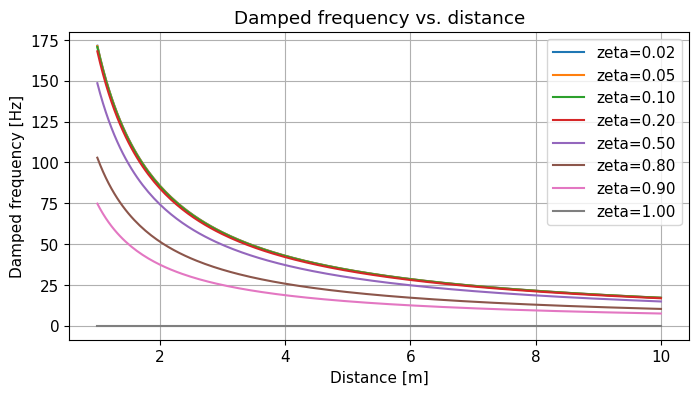

In [69]:
# Damped frequency vs. distance for multiple zeta values
c = 343.0  # m/s (sound); swap to 3e8 for radar
d = np.linspace(1.0, 10.0, 200)
wn = np.pi * c / d

zeta_vals = [0.02, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 1]
plt.figure(figsize=(8, 4))
for zeta_val in zeta_vals:
    wd = wn * np.sqrt(1 - zeta_val**2)
    plt.plot(d, wd/(2*np.pi), label=f'zeta={zeta_val:.2f}')

plt.title('Damped frequency vs. distance')
plt.xlabel('Distance [m]')
plt.ylabel('Damped frequency [Hz]')
plt.legend()
plt.show()


### 2) Choosing $Q$ (and $\zeta$) from Distance Spacing
If neurons are placed to cover distances $d_i$ with spacing $\Delta d$, a natural choice is to set each
neuron's bandwidth to match the spacing in frequency. For lightly damped systems,
$$
BW \approx \frac{\omega_n}{Q} \approx 2\zeta\omega_n.
$$
Using $\omega_n(d) = \pi c / d$, the local frequency spacing from a distance step is
$$
\Delta\omega \approx \left|\frac{d\omega_n}{dd}\right|\Delta d = \frac{\pi c}{d^2}\Delta d.
$$
So a practical tuning rule is
$$
Q(d) \approx \frac{\omega_n(d)}{\Delta\omega} = \frac{d}{\Delta d},
\quad
\zeta(d) \approx \frac{1}{2Q(d)} = \frac{\Delta d}{2d}.
$$
This keeps each neuron's resonance peak aligned with its desired distance and reduces excessive overlap.

We compute $Q$ and $\zeta$ for a bank of neurons and overlay their Bode magnitudes to verify that
the peak aligns with the desired tuned frequency.


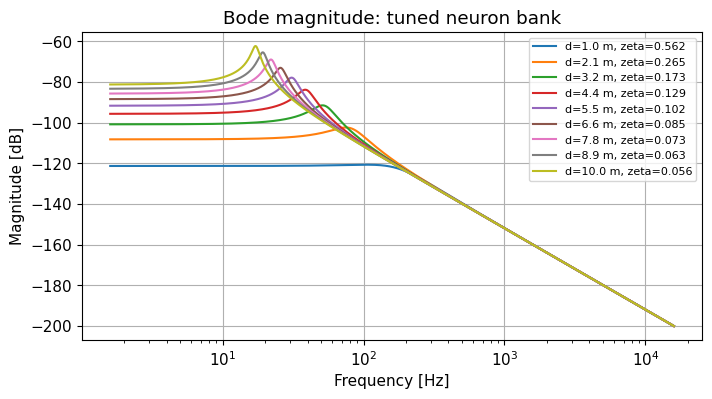

Neuron bank parameters:
d=1.00 m -> wn=1077.57 rad/s (171.50 Hz), Q=0.89, zeta=0.5625
d=2.12 m -> wn=507.09 rad/s (80.71 Hz), Q=1.89, zeta=0.2647
d=3.25 m -> wn=331.56 rad/s (52.77 Hz), Q=2.89, zeta=0.1731
d=4.38 m -> wn=246.30 rad/s (39.20 Hz), Q=3.89, zeta=0.1286
d=5.50 m -> wn=195.92 rad/s (31.18 Hz), Q=4.89, zeta=0.1023
d=6.62 m -> wn=162.65 rad/s (25.89 Hz), Q=5.89, zeta=0.0849
d=7.75 m -> wn=139.04 rad/s (22.13 Hz), Q=6.89, zeta=0.0726
d=8.88 m -> wn=121.42 rad/s (19.32 Hz), Q=7.89, zeta=0.0634
d=10.00 m -> wn=107.76 rad/s (17.15 Hz), Q=8.89, zeta=0.0562


In [ ]:
# Bank of neurons: choose Q and zeta from distance spacing
c = 343.0  # m/s (sound)
d_min, d_max, N = 1.0, 10.0, 9
d_bank = np.linspace(d_min, d_max, N)
delta_d = d_bank[1] - d_bank[0]

# Desired natural frequencies from distance
wn_bank = np.pi * c / d_bank

# Q and zeta from spacing rule (lightly damped approximation)
Q_bank = d_bank / delta_d
zeta_bank = 1.0 / (2.0 * Q_bank)

# Keep zeta in resonant regime (zeta < 1/sqrt(2))
zeta_bank = np.minimum(zeta_bank, 0.49)

# Bode plots for all tuned neurons
w = np.logspace(1, 5, 1200)  # rad/s
plt.figure(figsize=(8, 4))
for di, wn_i, zeta_i in zip(d_bank, wn_bank, zeta_bank):
    sys = signal.TransferFunction([1.0], [1.0, 2*zeta_i*wn_i, wn_i**2])
    _, mag, _ = signal.bode(sys, w=w)
    plt.semilogx(w/(2*np.pi), mag, label=f'd={di:.1f} m, zeta={zeta_i:.3f}')

plt.title('Bode magnitude: tuned neuron bank')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.legend(fontsize=8)
plt.show()

print('Neuron bank parameters:')
for di, wn_i, Q_i, zeta_i in zip(d_bank, wn_bank, Q_bank, zeta_bank):
    print(f'd={di:.2f} m -> wn={wn_i:.2f} rad/s ({wn_i/(2*np.pi):.2f} Hz), Q={Q_i:.2f}, zeta={zeta_i:.4f}')


### 3) Formalized Distance-to-Tuning Equations
**Time-of-Flight and Natural Frequency**
$$
\tau(d) = \frac{2d}{c},
\quad
\omega_n(d) = \frac{2\pi}{\tau(d)} = \frac{\pi c}{d}.
$$

**Damped Frequency and Resonant Peak**
$$
\omega_d(d,\zeta) = \omega_n(d)\sqrt{1-\zeta^2},
$$
and for $\zeta < 1/\sqrt{2}$, the magnitude peak occurs near
$$
\omega_{peak}(d,\zeta) = \omega_n(d)\sqrt{1-2\zeta^2}.
$$

**Quality Factor and Bandwidth**
$$
Q = \frac{1}{2\zeta},
\quad
BW \approx \frac{\omega_n}{Q} \approx 2\zeta\omega_n.
$$

**Distance-Spacing Rule (Tuning for a Bank)**
If neurons are spaced by $\Delta d$, then the corresponding frequency spacing is
$$
\Delta\omega(d) \approx \left|\frac{d\omega_n}{dd}\right|\Delta d = \frac{\pi c}{d^2}\Delta d.
$$
Choosing $BW \approx \Delta\omega$ gives
$$
Q(d) \approx \frac{\omega_n(d)}{\Delta\omega(d)} = \frac{d}{\Delta d},
\quad
\zeta(d) \approx \frac{\Delta d}{2d}.
$$


To ensure every neuron in your bank has a uniform sensitivity (i.e., the peak of the Bode plot always hits the same magnitude), we must apply **Impedance Matching** or **Peak Normalization**.

In control theory, the peak magnitude of a second-order resonant system is $M_p \approx \frac{1}{2\zeta}$. To normalize this to $1.0$, we must multiply the input by $2\zeta$. However, because your neurons are tuned to different frequencies ($\omega_n$), we must also account for the frequency-dependent scaling of the integrator.

---

## 1. The Math of Peak Normalization
The transfer function for the Resonate-and-Fire neuron (voltage $V$ over input $I$) is:

$$H(s) = \frac{1}{s^2 + 2\zeta\omega_n s + \omega_n^2}$$

### The Gain at Resonance
At resonance ($s = j\omega_n$), the magnitude is:

$$|H(j\omega_n)| = \frac{1}{|(j\omega_n)^2 + 2\zeta\omega_n(j\omega_n) + \omega_n^2|} = \frac{1}{|-\omega_n^2 + 2j\zeta\omega_n^2 + \omega_n^2|} = \frac{1}{2\zeta\omega_n^2}$$

### The Normalization Factor ($G_{norm}$)
To make the peak magnitude equal to a target value (e.g., $1.0$), the required gain is:

$$G_{norm} = 2\zeta\omega_n^2$$
**Why this is elegant:**
1. **$\zeta$ scaling:** As you observed, higher damping "squashes" the peak. Multiplying by $\zeta$ pushes it back up.
2. **$\omega_n^2$ scaling:** High-frequency "springs" are stiffer. They require more "force" (current) to move the same distance (voltage) as low-frequency springs.

---

## 2. Implementation: The Normalized Filter Bank
Below is the Python code to generate a bank of neurons where each peak is normalized. I have included a section to plot the **Bode Magnitude** so you can see the uniform peaks.

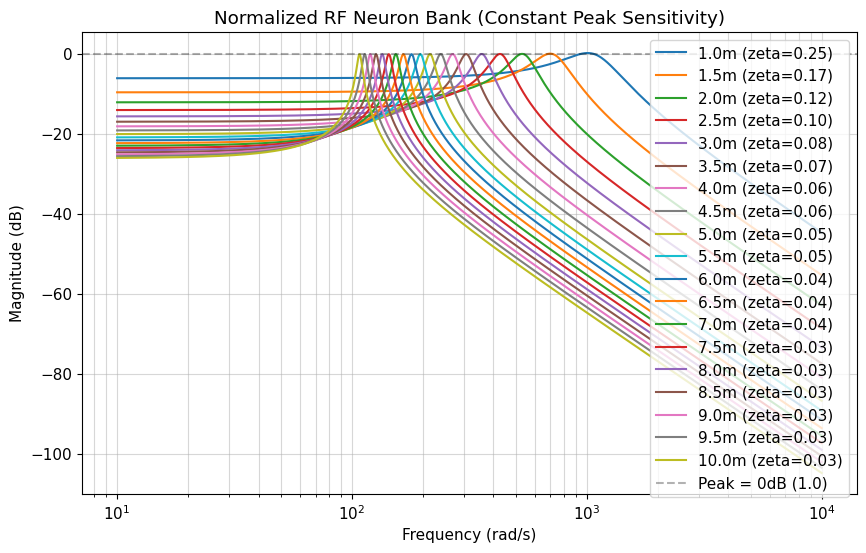

In [71]:
def create_resonant_bank(distances, delta_d, c=343.0):
    """
    Creates a bank of RF neurons tuned to specific distances with 
    normalized peak amplitudes.
    """
    bank_params = []
    
    for d in distances:
        # 1. Calculate Natural Frequency based on distance
        # Period T = 2d/c -> f = 1/T = c/(2d) -> omega = 2*pi*f
        omega_n = (np.pi * c) / d
        
        # 2. Calculate Q and zeta based on your spacing rule
        # Q = d / delta_d
        Q = d / delta_d
        zeta = 1.0 / (2.0 * Q)
        
        # 3. Calculate Normalization Gain
        # To make peak = 1.0, Gain = 2 * zeta * omega_n^2
        gain = 2 * zeta * (omega_n**2)
        
        bank_params.append({
            'd': d,
            'omega_n': omega_n,
            'zeta': zeta,
            'gain': gain
        })
        
    return bank_params

# Setup
c = 343.0 # Speed of sound
delta_d = 0.5 # 50cm resolution
test_distances = np.linspace(1, 10, 19) # Neurons from 2m to 10m

bank = create_resonant_bank(test_distances, delta_d, c)

# Plotting
plt.figure(figsize=(10, 6))
w = np.logspace(1, 4, 1000) # Frequency range for Bode plot

for p in bank:
    # System: H(s) = gain / (s^2 + 2*zeta*wn*s + wn^2)
    num = [p['gain']]
    den = [1, 2 * p['zeta'] * p['omega_n'], p['omega_n']**2]
    
    w_out, mag, phase = signal.bode((num, den), w)
    
    # Convert omega to distance for the label
    dist_label = f"{p['d']}m (zeta={p['zeta']:.2f})"
    plt.semilogx(w_out, mag, label=dist_label)

plt.title("Normalized RF Neuron Bank (Constant Peak Sensitivity)")
plt.xlabel("Frequency (rad/s)")
plt.ylabel("Magnitude (dB)")
plt.axhline(0, color='black', linestyle='--', alpha=0.3, label="Peak = 0dB (1.0)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


## 3. Reasoning and Insights
### Uniform Sensitivity vs. Biological Reality
While the code above makes every neuron equally sensitive, in a real Bat Echolocation scenario, you might actually not want total normalization.
* **The Inverse Square Law:** Sound intensity drops as $1/d^2$.
* **The Solution:** You can adjust the gain parameter to specifically compensate for this. By making the far-distance neurons (large $d$) even more sensitive than the near-distance ones, you create a "Hardware AGC" (Automatic Gain Control) built directly into the physics of your neurons.
### The Damping Trade-off
Notice in your Bode plot that the **Near-field neurons (low $Q$, high $\zeta$)** have a much wider "shoulder."
* **The Good:** They are very robust to small variations in frequency (or speed of sound changes due to temperature).
* **The Bad:** They respond to a lot of "off-target" noise.
* **The Fix:** Because near-field signals are usually much stronger, the wide bandwidth is acceptable a**s the Signal-to-Noise Ratio (SNR) is high.
### Control Theory Perspective
By using $G_{norm} = 2\zeta\omega_n^2$, you are essentially transforming the neuron from a simple "spring" into a **Matched Filter**. You are ensuring that regardless of the "stiffness" of the filter (its frequency), the energy required to trigger a spike remains constant.

## Biologically-Inspired Logarithmic RF Banks

### Part 1: Biology and Logarithmic Mapping
**Weber-Fechner Law**: many biological systems encode stimulus magnitude on a logarithmic scale.
Perceptual sensitivity is proportional to fractional change ($\Delta x / x$), not absolute change ($\Delta x$).
This leads naturally to logarithmic spacing of receptive fields.

**Resolution Problem in Linear Banks**: with linear distance spacing,\
$$\omega_n(d) = \pi c / d \Rightarrow \Delta\omega \propto d^{-2}.$$
To keep peaks separated at large $d$, the required bandwidth shrinks rapidly, forcing $Q$ to grow
without bound. This is not biologically realistic.

**Logarithmic Spacing Fixes This**: if the bank enforces constant fractional resolution,
$ \frac{\Delta d}{d} = K $ (constant), then $Q$ and $\zeta$ become constant across neurons.
Using $BW \approx 2\zeta\omega_n$ and $\Delta\omega \approx \left|\frac{d\omega_n}{dd}\right|\Delta d$,
we get
$$
\Delta\omega \approx \frac{\omega_n}{d}\Delta d = K\omega_n,
\quad
Q \approx \frac{\omega_n}{\Delta\omega} = \frac{1}{K},
\quad
\zeta \approx \frac{1}{2Q} = \frac{K}{2}.
$$
Thus a log-spaced bank achieves a constant-$Q$ property like the cochlea.


### Part 2: Mathematical Framework
**Logarithmic spacing** (distance of the $i$-th neuron):
$$
d_i = d_{min} \left(\frac{d_{max}}{d_{min}}\right)^{i/(N-1)}.
$$
**Natural frequency**:
$$
\omega_n(d) = \frac{\pi c}{d}.
$$
**Local spacing**:
$$
\Delta d_i \approx d_i \cdot \frac{\ln(d_{max}/d_{min})}{N-1}.
$$
**Constant damping ratio** (from log spacing):
$$
\zeta = \frac{\ln(d_{max}/d_{min})}{2(N-1)}.
$$
**Impedance normalization gain** (uniform peak sensitivity):
$$
G = 2\zeta\omega_n^2.
$$


In [72]:
def create_log_resonant_bank(d_min, d_max, n_neurons, c=343.0):
    # Log-spaced distances
    idx = np.arange(n_neurons)
    d = d_min * (d_max / d_min) ** (idx / (n_neurons - 1))

    # Constant damping ratio from log spacing
    zeta = np.log(d_max / d_min) / (2 * (n_neurons - 1))

    # Natural frequency and normalization gain
    wn = np.pi * c / d
    G = 2 * zeta * wn**2

    bank = []
    for di, wni, Gi in zip(d, wn, G):
        bank.append({
            'd': float(di),
            'omega_n': float(wni),
            'zeta': float(zeta),
            'gain': float(Gi),
        })
    return bank

# Example usage
bank = create_log_resonant_bank(1.0, 10.0, 10, c=343.0)
bank[:3]


[{'d': 1.0,
  'omega_n': 1077.5662801812991,
  'zeta': 0.12792139405522476,
  'gain': 297071.6201328399},
 {'d': 1.2915496650148839,
  'omega_n': 834.3204364261759,
  'zeta': 0.12792139405522476,
  'gain': 178089.75748636876},
 {'d': 1.6681005372000588,
  'omega_n': 645.984013643456,
  'zeta': 0.12792139405522476,
  'gain': 106762.00475619778}]

### Part 3: Implementation and Visualization
We compare Bode magnitudes of the logarithmic bank on a log-frequency axis.
With constant $\zeta$ (constant $Q$), the filter widths appear uniform in log-frequency space.


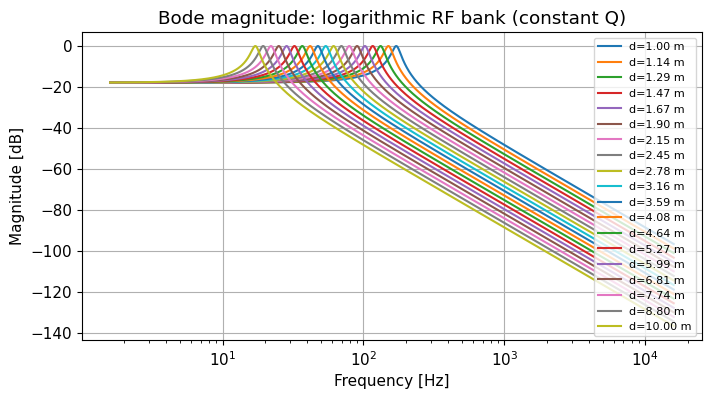

In [73]:
# Bode plot comparison for log-spaced bank
bank = create_log_resonant_bank(1.0, 10.0, 19, c=343.0)
w = np.logspace(1, 5, 1200)  # rad/s
plt.figure(figsize=(8, 4))
for neuron in bank:
    wn_i = neuron['omega_n']
    zeta_i = neuron['zeta']
    G_i = neuron['gain']
    sys = signal.TransferFunction([G_i], [1.0, 2*zeta_i*wn_i, wn_i**2])
    _, mag, _ = signal.bode(sys, w=w)
    plt.semilogx(w/(2*np.pi), mag, label='d={:.2f} m'.format(neuron['d']))

plt.title('Bode magnitude: logarithmic RF bank (constant Q)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.legend(fontsize=8)
plt.show()


**Impulse Response Comparison**: a far-field neuron has a lower $\omega_n$,
so its oscillations are slower in absolute time. With constant $\zeta$,
both neurons have the same *relative* damping, but the far-field response
rings longer in seconds.


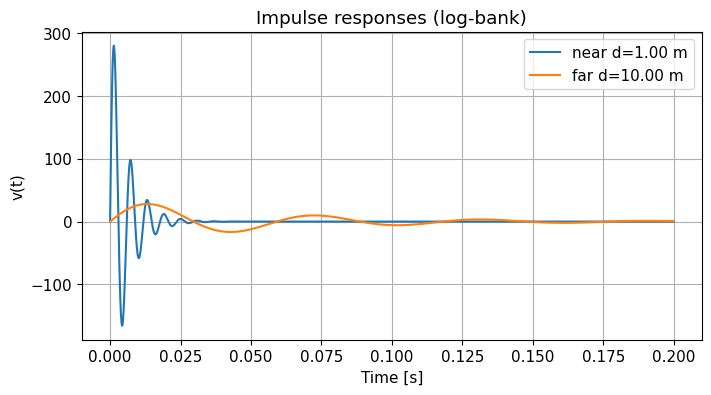

In [74]:
# Impulse response: near-field vs far-field
bank = create_log_resonant_bank(1.0, 10.0, 8, c=343.0)
near = bank[0]
far = bank[-1]

t = np.linspace(0, 0.2, 4000)

def impulse_resp_scaled(t, wn, zeta, gain):
    wd = wn * np.sqrt(1 - zeta**2)
    h = np.zeros_like(t)
    mask = t >= 0
    h[mask] = gain * np.exp(-zeta*wn*t[mask]) * np.sin(wd*t[mask]) / wd
    return h

h_near = impulse_resp_scaled(t, near['omega_n'], near['zeta'], near['gain'])
h_far = impulse_resp_scaled(t, far['omega_n'], far['zeta'], far['gain'])

plt.figure(figsize=(8, 4))
plt.plot(t, h_near, label='near d={:.2f} m'.format(near['d']))
plt.plot(t, h_far, label='far d={:.2f} m'.format(far['d']))
plt.title('Impulse responses (log-bank)')
plt.xlabel('Time [s]')
plt.ylabel('v(t)')
plt.legend()
plt.show()


### Part 4: Bat-Style Echo Simulation with a Log Bank
We emit a call at $t=0$ and receive an echo at $t = 2d_{target}/c$.
Passing this through the log RF bank yields an activation map that is
dense for near targets and still extends to far targets, with a constant-Q profile.


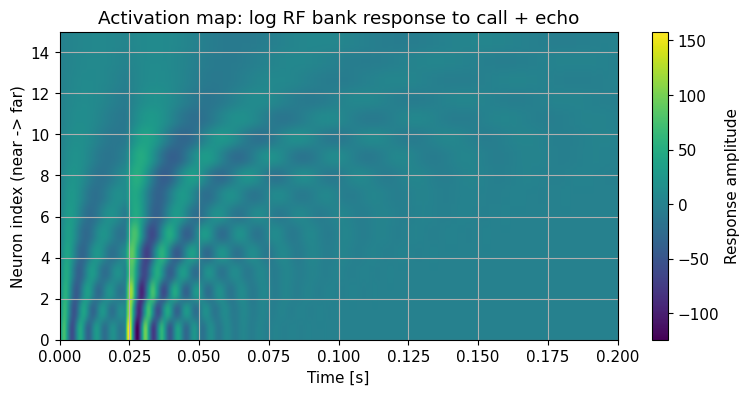

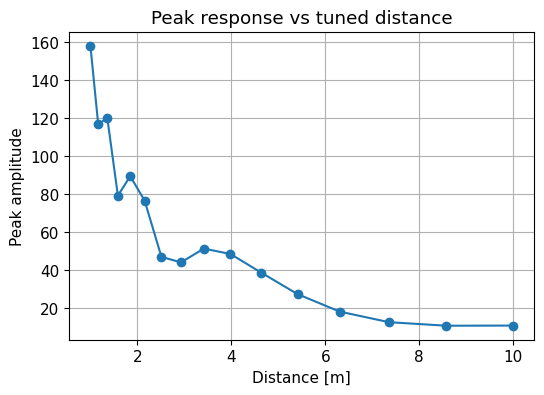

In [75]:
# Bat-style echo simulation
c = 343.0
d_target = 4.0  # meters
t_echo = 2 * d_target / c

t = np.linspace(0, 0.2, 4000)
u = np.zeros_like(t)

# Approximate impulses with narrow pulses
dt = t[1] - t[0]
u[0] = 1.0 / dt
echo_idx = np.argmin(np.abs(t - t_echo))
u[echo_idx] = 1.0 / dt

bank = create_log_resonant_bank(1.0, 10.0, 16, c=c)

responses = []
for neuron in bank:
    wn_i = neuron['omega_n']
    zeta_i = neuron['zeta']
    G_i = neuron['gain']
    sys = signal.TransferFunction([G_i], [1.0, 2*zeta_i*wn_i, wn_i**2])
    tout, y, _ = signal.lsim(sys, U=u, T=t)
    responses.append(y)

responses = np.array(responses)

plt.figure(figsize=(9, 4))
plt.imshow(responses, aspect='auto', origin='lower',
           extent=[t[0], t[-1], 0, len(bank)-1])
plt.colorbar(label='Response amplitude')
plt.title('Activation map: log RF bank response to call + echo')
plt.xlabel('Time [s]')
plt.ylabel('Neuron index (near -> far)')
plt.show()

# Peak response vs distance (sanity check)
peak = responses.max(axis=1)
dist = np.array([n['d'] for n in bank])
plt.figure(figsize=(6, 4))
plt.plot(dist, peak, marker='o')
plt.title('Peak response vs tuned distance')
plt.xlabel('Distance [m]')
plt.ylabel('Peak amplitude')
plt.show()


## Section 5: Stability and Discrete-Time Realism

We analyze stability in both continuous time (pole constellation in the $s$-plane) and
discrete time (poles in the $z$-plane). We use both linear and logarithmic distance banks.

Key relations:
- Continuous poles: $s = -\zeta\omega_n \pm j\omega_d$
- Damped frequency: $\omega_d = \omega_n\sqrt{1-\zeta^2}$
- Approx. settling time (2%): $T_s \approx 4/\sigma$ with $\sigma = \zeta\omega_n$

For discrete-time realizations we use a bilinear transform (Tustin) as a stable,
frequency-warping-preserving mapping. For symplectic Euler, the discrete poles
are the eigenvalues of the one-step update matrix.


In [76]:
# Helper: create linear and log-spaced banks
def create_linear_bank(d_min, d_max, n_neurons, c=343.0):
    d = np.linspace(d_min, d_max, n_neurons)
    if n_neurons > 1:
        delta_d = d[1] - d[0]
    else:
        delta_d = d_min
    wn = np.pi * c / d
    zeta = np.minimum(delta_d / (2.0 * d), 0.49)
    G = 2 * zeta * wn**2
    bank = []
    for di, wni, zi, Gi in zip(d, wn, zeta, G):
        bank.append({
            'd': float(di),
            'omega_n': float(wni),
            'zeta': float(zi),
            'gain': float(Gi),
        })
    return bank

if 'create_log_resonant_bank' not in globals():
    def create_log_resonant_bank(d_min, d_max, n_neurons, c=343.0):
        idx = np.arange(n_neurons)
        d = d_min * (d_max / d_min) ** (idx / (n_neurons - 1))
        zeta = np.log(d_max / d_min) / (2 * (n_neurons - 1))
        wn = np.pi * c / d
        G = 2 * zeta * wn**2
        bank = []
        for di, wni, Gi in zip(d, wn, G):
            bank.append({
                'd': float(di),
                'omega_n': float(wni),
                'zeta': float(zeta),
                'gain': float(Gi),
            })
        return bank

# Example banks
c = 343.0
d_min, d_max, N = 1.0, 10.0, 10
linear_bank = create_linear_bank(d_min, d_max, N, c=c)
log_bank = create_log_resonant_bank(d_min, d_max, N, c=c)


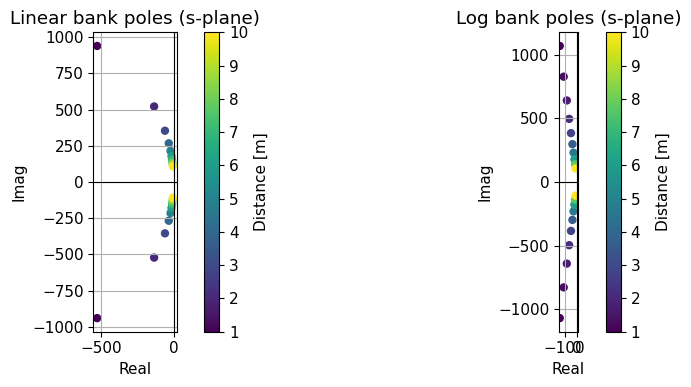

In [83]:
# Pole constellation for the entire bank (continuous-time)
def collect_poles(bank):
    real = []
    imag = []
    dist = []
    for neuron in bank:
        wn_i = neuron['omega_n']
        zeta_i = neuron['zeta']
        G_i = neuron['gain']
        z, p, k = signal.tf2zpk([G_i], [1.0, 2*zeta_i*wn_i, wn_i**2])
        for pole in p:
            real.append(pole.real)
            imag.append(pole.imag)
            dist.append(neuron['d'])
    return np.array(real), np.array(imag), np.array(dist)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=False, sharey=False)

real, imag, dist = collect_poles(linear_bank)
sc = ax[0].scatter(real, imag, c=dist, cmap='viridis', s=25)
ax[0].axhline(0, color='k', linewidth=0.8)
ax[0].axvline(0, color='k', linewidth=0.8)
ax[0].set_title('Linear bank poles (s-plane)')
ax[0].set_xlabel('Real')
ax[0].set_ylabel('Imag')
ax[0].set_aspect('equal', adjustable='box')
fig.colorbar(sc, ax=ax[0], label='Distance [m]')

real, imag, dist = collect_poles(log_bank)
sc = ax[1].scatter(real, imag, c=dist, cmap='viridis', s=25)
ax[1].axhline(0, color='k', linewidth=0.8)
ax[1].axvline(0, color='k', linewidth=0.8)
ax[1].set_title('Log bank poles (s-plane)')
ax[1].set_xlabel('Real')
ax[1].set_ylabel('Imag')
ax[1].set_aspect('equal', adjustable='box')
fig.colorbar(sc, ax=ax[1], label='Distance [m]')

plt.tight_layout()
plt.show()


As tuned distance increases, $\omega_n$ decreases, and the poles move toward the origin
in both real and imaginary directions. The real part $-\zeta\omega_n$ sets the decay rate,
and therefore the settling time.


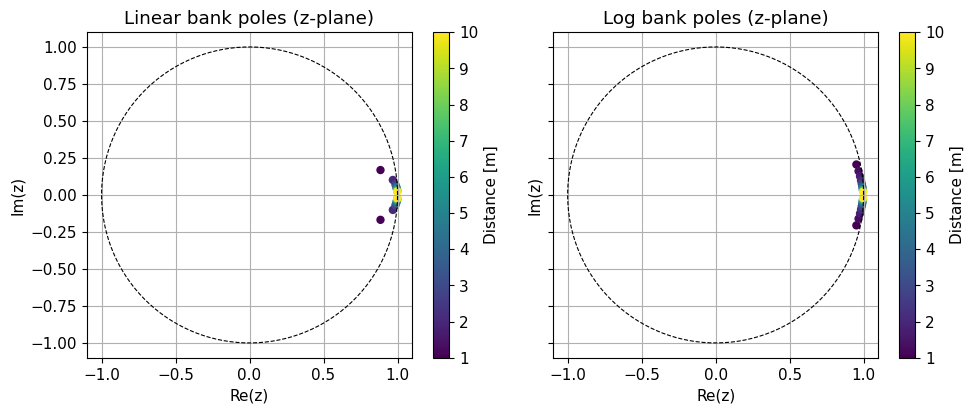

In [86]:
# Discrete-time poles via bilinear transform
fs = 5000.0
dt = 1.0 / fs

def collect_z_poles(bank, dt):
    real = []
    imag = []
    dist = []
    for neuron in bank:
        wn_i = neuron['omega_n']
        zeta_i = neuron['zeta']
        G_i = neuron['gain']
        num = [G_i]
        den = [1.0, 2*zeta_i*wn_i, wn_i**2]
        numz, denz, _ = signal.cont2discrete((num, den), dt, method='bilinear')
        z, p, k = signal.tf2zpk(numz.flatten(), denz)
        for pole in p:
            real.append(pole.real)
            imag.append(pole.imag)
            dist.append(neuron['d'])
    return np.array(real), np.array(imag), np.array(dist)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
theta = np.linspace(0, 2*np.pi, 400)
uc_x = np.cos(theta)
uc_y = np.sin(theta)

real, imag, dist = collect_z_poles(linear_bank, dt)
ax[0].plot(uc_x, uc_y, 'k--', linewidth=0.8)
sc = ax[0].scatter(real, imag, c=dist, cmap='viridis', s=25)
ax[0].set_title('Linear bank poles (z-plane)')
ax[0].set_xlabel('Re(z)')
ax[0].set_ylabel('Im(z)')
ax[0].set_aspect('equal', adjustable='box')
fig.colorbar(sc, ax=ax[0], label='Distance [m]')

real, imag, dist = collect_z_poles(log_bank, dt)
ax[1].plot(uc_x, uc_y, 'k--', linewidth=0.8)
sc = ax[1].scatter(real, imag, c=dist, cmap='viridis', s=25)
ax[1].set_title('Log bank poles (z-plane)')
ax[1].set_xlabel('Re(z)')
ax[1].set_ylabel('Im(z)')
ax[1].set_aspect('equal', adjustable='box')
fig.colorbar(sc, ax=ax[1], label='Distance [m]')

plt.tight_layout()
plt.show()


**Sampling Limit (Nyquist)**: The highest natural frequency is at the smallest distance.
With $\omega_n(d)=\pi c/d$, the corresponding frequency is $f_n(d)=c/(2d)$.
Nyquist requires $f_n(d_{min}) < f_s/2$, so
$$
d_{min} \gtrsim \frac{c}{f_s}.
$$
This sets a hardware sampling constraint on the minimum resolvable distance.


In [87]:
# Nyquist-implied minimum distance for the chosen sampling rate
d_min_nyquist = c / fs
print(f'For f_s = {fs:.1f} Hz, Nyquist suggests d_min >= {d_min_nyquist:.4f} m')


For f_s = 5000.0 Hz, Nyquist suggests d_min >= 0.0686 m


### Impulse Response vs. Pole Location
The settling time is tied to the pole real part: $\sigma = \zeta\omega_n$,
so $T_s \approx 4/\sigma$. This directly explains why far-field neurons
(lower $\omega_n$) ring longer in absolute time.


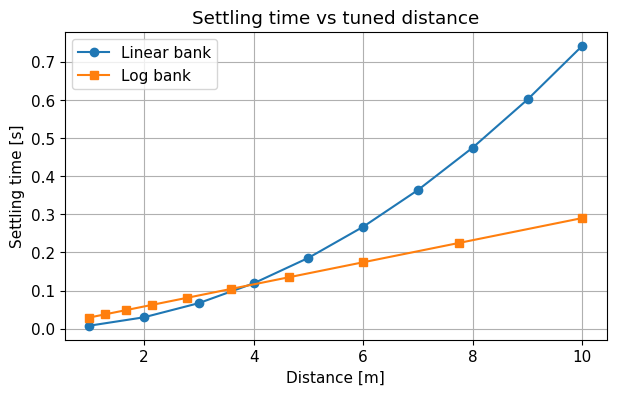

In [80]:
# Settling time vs distance for linear and log banks
def settling_time(bank):
    d = np.array([n['d'] for n in bank])
    sigma = np.array([n['zeta'] * n['omega_n'] for n in bank])
    ts = 4.0 / sigma
    return d, ts

d_lin, ts_lin = settling_time(linear_bank)
d_log, ts_log = settling_time(log_bank)

plt.figure(figsize=(7, 4))
plt.plot(d_lin, ts_lin, marker='o', label='Linear bank')
plt.plot(d_log, ts_log, marker='s', label='Log bank')
plt.title('Settling time vs tuned distance')
plt.xlabel('Distance [m]')
plt.ylabel('Settling time [s]')
plt.legend()
plt.show()
